In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

2026-03-19 07:35:38.852115: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773905739.035425      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773905739.082241      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773905739.470093      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773905739.470137      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773905739.470139      24 computation_placer.cc:177] computation placer alr

In [2]:
train_path = '/kaggle/input/datasets/adlinhedilisyam/test-deepfake/dataset_split/train'
val_path   = '/kaggle/input/datasets/adlinhedilisyam/test-deepfake/dataset_split/val'
test_path  = '/kaggle/input/datasets/adlinhedilisyam/test-deepfake/dataset_split/test'

In [3]:

from sklearn.utils.class_weight import compute_class_weight

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    shear_range=0.1,
    fill_mode='nearest'
)
val_gen  = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data_heavy = train_gen.flow_from_directory(
    train_path, target_size=(224, 224),
    batch_size=32, class_mode='binary'
)
val_data = val_gen.flow_from_directory(
    val_path, target_size=(224, 224),
    batch_size=32, class_mode='binary'
)
test_data = test_gen.flow_from_directory(
    test_path, target_size=(224, 224),
    batch_size=32, class_mode='binary',
    shuffle=False
)

labels = train_data_heavy.classes
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights_array))
print("Classes     :", train_data_heavy.class_indices)
print("Class weights:", class_weight_dict)

Found 1428 images belonging to 2 classes.
Found 306 images belonging to 2 classes.
Found 307 images belonging to 2 classes.
Classes     : {'training_fake': 0, 'training_real': 1}
Class weights: {0: np.float64(1.0625), 1: np.float64(0.9444444444444444)}


In [4]:
from tensorflow.keras.layers import BatchNormalization

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=1e-4),   
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

I0000 00:00:1773905758.773162      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773905758.779008      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,624,065 (10.01 MB)

 Trainable params: 2,587,393 (9.87 MB)

 Non-trainable params: 36,672 (143.25 KB)

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',       
        save_best_only=True,
        verbose=1
    )
]

history1 = model.fit(
    train_data_heavy,                  
    validation_data=val_data,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=callbacks
)
print(f"Best val_accuracy: {max(history1.history['val_accuracy'])*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1773905787.289870      91 service.cc:152] XLA service 0x7f5f900020f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773905787.289911      91 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773905787.289918      91 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773905791.529159      91 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-19 07:36:41.324843: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-19 07:36:41.463068: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1773905820.433871      91 device_co

 3/45 ━━━━━━━━━━━━━━━━━━━━ 18s 430ms/step - accuracy: 0.5087 - loss: 0.9283

2026-03-19 07:37:16.060183: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-19 07:37:16.197114: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5096 - loss: 0.9027

2026-03-19 07:38:20.415987: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-19 07:38:20.553503: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from -inf to 0.47386, saving model to best_model.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.5101 - loss: 0.9020 - val_accuracy: 0.4739 - val_loss: 0.9007 - learning_rate: 1.0000e-04
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.5520 - loss: 0.8121
Epoch 2: val_accuracy improved from 0.47386 to 0.48039, saving model to best_model.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 31s 690ms/step - accuracy: 0.5528 - loss: 0.8108 - val_accuracy: 0.4804 - val_loss: 0.9334 - learning_rate: 1.0000e-04
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 621ms/step - accuracy: 0.6303 - loss: 0.6766
Epoch 3: val_accuracy improved from 0.48039 to 0.51634, saving model to best_model.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 32s 698ms/step - accuracy: 0.6305 - loss: 0.6766 - val_accuracy: 0.5163 - val_loss: 0.8553 - learning_rate: 1.0000e-04
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.6860 - loss: 0.6108
Epoch 4: val_accuracy improved from 0.516

In [6]:

model.load_weights('best_model.keras')

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_ft.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

history2 = model.fit(
    train_data_heavy,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=callbacks_ft
)
print(f"Fine-tune best val_accuracy: {max(history2.history['val_accuracy'])*100:.2f}%")

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9580 - loss: 0.1251
Epoch 1: val_accuracy improved from -inf to 0.66013, saving model to best_model_ft.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9581 - loss: 0.1250 - val_accuracy: 0.6601 - val_loss: 0.9956
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.9563 - loss: 0.1091
Epoch 2: val_accuracy did not improve from 0.66013
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 675ms/step - accuracy: 0.9563 - loss: 0.1089 - val_accuracy: 0.6471 - val_loss: 1.0625
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.9699 - loss: 0.0934
Epoch 3: val_accuracy did not improve from 0.66013
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 663ms/step - accuracy: 0.9699 - loss: 0.0934 - val_accuracy: 0.6438 - val_loss: 1.1046
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.9637 - loss: 0.1152
Epoch 4: val_accuracy did not improve from 0.66013
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 668ms/step - accuracy: 0.9636 - lo

In [7]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.5384 - loss: 1.9529

2026-03-19 08:07:52.691534: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-19 08:07:52.831923: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-19 08:07:52.969672: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5602 - loss: 1.8258
Test Accuracy: 0.6579804420471191


10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 701ms/step


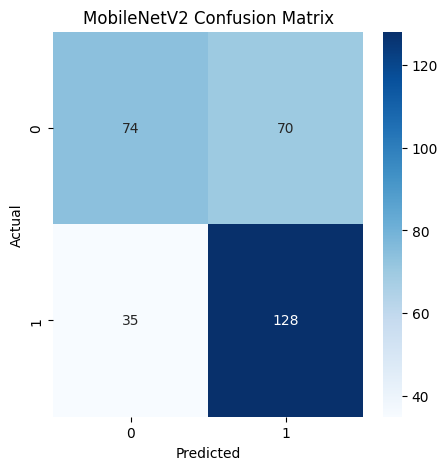

In [8]:
y_pred = model.predict(test_data)
y_pred_classes = (y_pred > 0.5).astype(int).ravel()
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 Confusion Matrix")
plt.show()

In [9]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.68      0.51      0.58       144
           1       0.65      0.79      0.71       163

    accuracy                           0.66       307
   macro avg       0.66      0.65      0.65       307
weighted avg       0.66      0.66      0.65       307



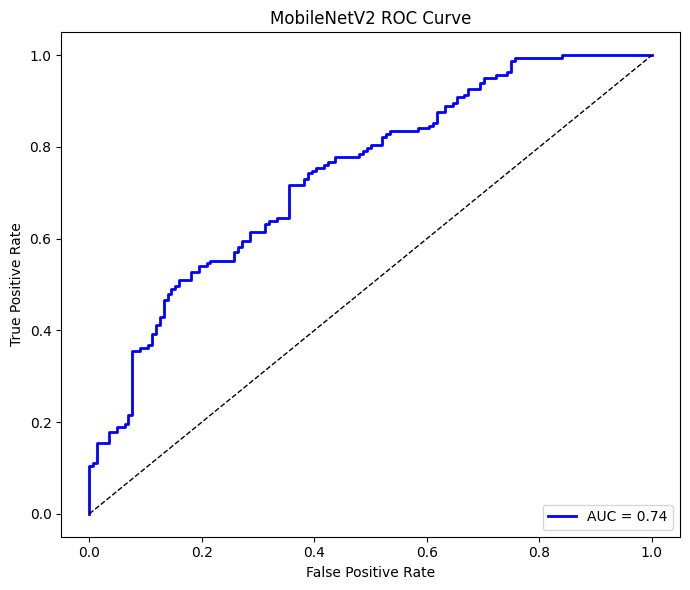

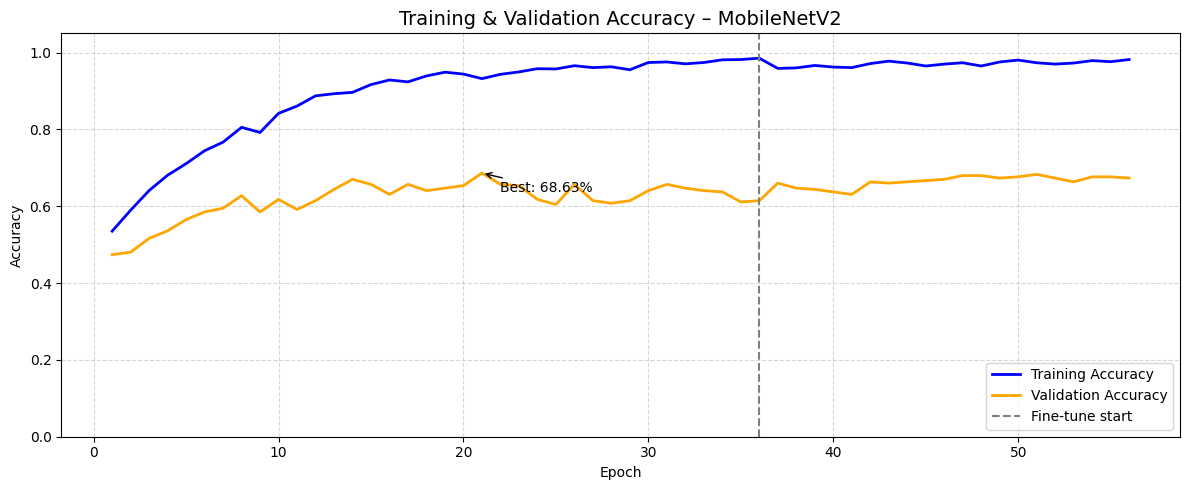

Best Training Accuracy  : 98.53%
Best Validation Accuracy: 68.63%
Achieved at Epoch       : 21


In [ ]:
# ROC Curve (binary) 
fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MobileNetV2 ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Accuracy Line Chart 
acc   = history1.history['accuracy']     + history2.history['accuracy']
vacc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
phase2_start = len(history1.history['accuracy'])
epochs_range = range(1, len(acc) + 1)

best_val_epoch = int(np.argmax(vacc)) + 1
best_val_acc   = max(vacc)

plt.figure(figsize=(12, 5))
plt.plot(epochs_range, acc,  label='Training Accuracy',   color='blue',   linewidth=2)
plt.plot(epochs_range, vacc, label='Validation Accuracy', color='orange', linewidth=2)
plt.axvline(x=phase2_start, color='grey', linestyle='--', linewidth=1.5, label='Fine-tune start')
plt.annotate(
    f'Best: {best_val_acc*100:.2f}%',
    xy=(best_val_epoch, best_val_acc),
    xytext=(best_val_epoch + 1, best_val_acc - 0.05),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10
)
plt.title('Training & Validation Accuracy – MobileNetV2', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1.05])
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Best Training Accuracy  : {max(acc)*100:.2f}%")
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}%")
print(f"Achieved at Epoch       : {best_val_epoch}")

In [11]:
model.save("deepfake_mobilenet_model.keras")